In [23]:
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
G = nx.florentine_families_graph()

In [11]:
num_nodes = G.number_of_nodes()
num_edges = G.number_of_edges()
density = nx.density(G)
components = list(nx.connected_components(G))

print(f"Number of nodes: {num_nodes}")
print(f"Number of edges: {num_edges}")
print(f"Density: {density:.4f}")
print(f"Number of connected components: {len(components)}")
print()

Number of nodes: 15
Number of edges: 20
Density: 0.1905
Number of connected components: 1



In [13]:
degree_dict = dict(G.degree())
top3 = sorted(degree_dict.items(), key=lambda x: x[1], reverse=True)[:3]

print("TOP 3 FAMILIES")
for family, degree in top3:
    print(f"{family}: {degree}")
print()


TOP 3 FAMILIES
Medici: 6
Strozzi: 4
Guadagni: 4



In [19]:
source = "Medici"
target = "Strozzi"

if not G.has_edge(source, target):
    shortest_path = nx.shortest_path(G, source=source, target=target)
    print("SHORTEST PATH")
    print(f"Shortest path {source} and {target}:")
    print(" -> ".join(shortest_path))
    print()

else:
    print(f"{source} and {target} are directly connected")

=== SHORTEST PATH ===
Shortest path Medici and Strozzi:
Medici -> Ridolfi -> Strozzi



Najkraći put između obitelji Medici i Strozzi prolazi kroz obitelj Ridolfi. To pokazuje da nisu sve važne obitelji direktno povezane, već ovise o drugim obiteljima koje ih međusobno povezuju i omogućuju da mreža ostane povezana.

Struktura ima smisla kroz povijesni kontekst, jer je obitelj Ridolfi bila povezana i s Medicijima i sa Strozzijima kroz brakove i političke odnose.

Obitelji koje se često pojavljuju u ovakvim putevima imaju važnu ulogu jer povezuju različite dijelove mreže i omogućuju tok utjecaja.

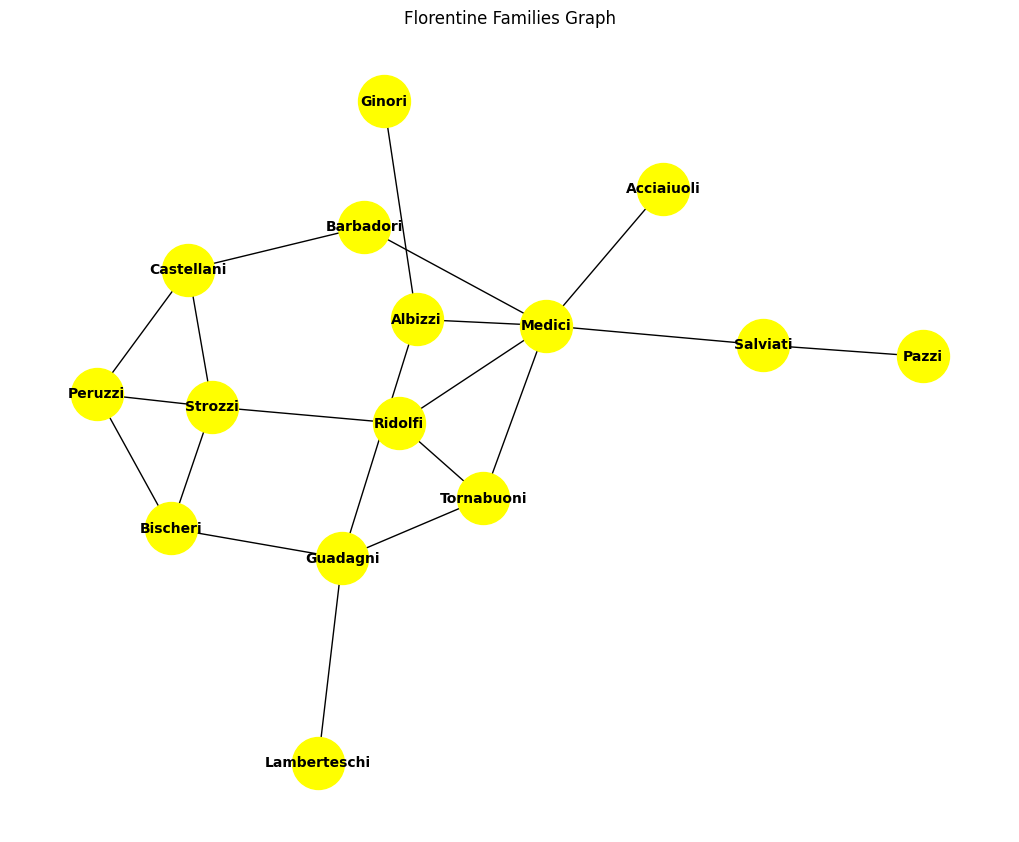

In [21]:
plt.figure(figsize=(10, 8))
pos = nx.spring_layout(G, seed=42)
nx.draw(
    G,
    pos,
    with_labels=True,
    node_color="yellow",
    node_size=1400,
    edge_color="black",
    font_size=10,
    font_weight="bold"
)
plt.title("Florentine Families Graph")
plt.show()

In [25]:
degrees = [deg for node, deg in G.degree()]
print(f"Nodes: {G.number_of_nodes()}")
print(f"Edges: {G.number_of_edges()}")
print(f"Density: {nx.density(G):.4f}")
print(f"Connected components: {len(list(nx.connected_components(G)))}")
print(f"Min degree: {min(degrees)}")
print(f"Max degree: {max(degrees)}")
print(f"Average degree: {sum(degrees)/len(degrees):.2f}")

summary = pd.DataFrame({
    "Metric": ["Nodes", "Edges", "Density", "Components", "Min Degree", "Max Degree", "Avg Degree"],
    "Value": [
        G.number_of_nodes(),
        G.number_of_edges(),
        round(nx.density(G), 4),
        len(list(nx.connected_components(G))),
        min(degrees),
        max(degrees),
        round(sum(degrees)/len(degrees), 2)
    ]
})

print("SUMMARY TABLE")
print(summary)

Nodes: 15
Edges: 20
Density: 0.1905
Connected components: 1
Min degree: 1
Max degree: 6
Average degree: 2.67
SUMMARY TABLE
       Metric    Value
0       Nodes  15.0000
1       Edges  20.0000
2     Density   0.1905
3  Components   1.0000
4  Min Degree   1.0000
5  Max Degree   6.0000
6  Avg Degree   2.6700


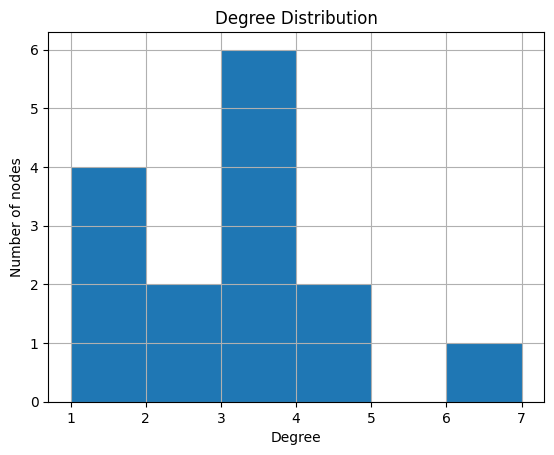

In [24]:
plt.figure()
plt.hist(degrees, bins=range(min(degrees), max(degrees)+2))
plt.title("Degree Distribution")
plt.xlabel("Degree")
plt.ylabel("Number of nodes")
plt.grid()
plt.show()